# Batch Gradient Descent

Batch Gradient Descent is an optimization algorithm used in machine learning to minimize a cost (loss) function by adjusting model parameters step-by-step.

## Key idea
- It uses the entire training dataset at once to compute the gradient (direction of steepest descent).
- Parameters are updated after processing the full dataset in each iteration (epoch).



## How it works
- Initialize parameters randomly (e.g., weights and bias in linear regression).
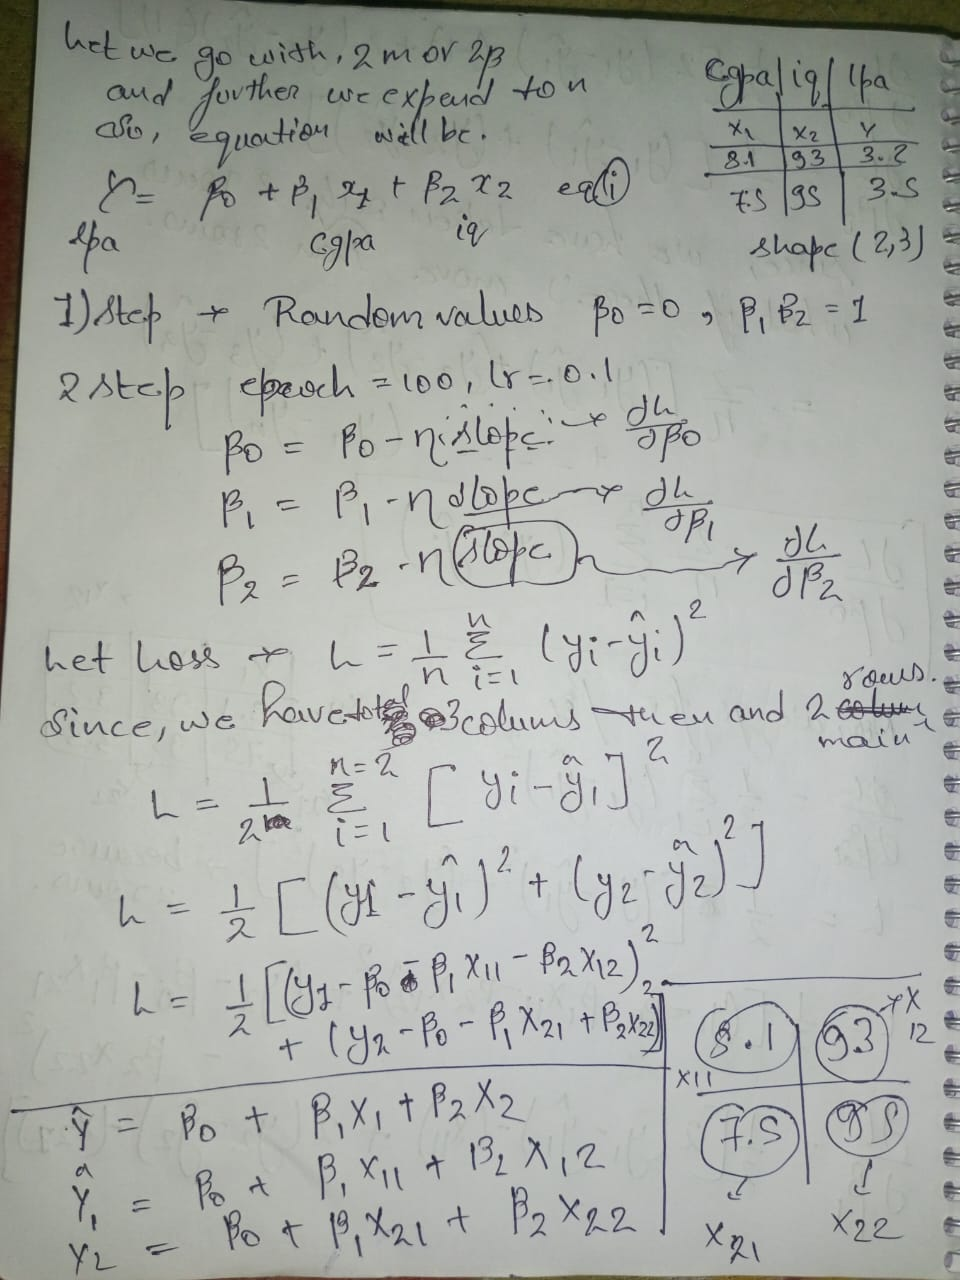

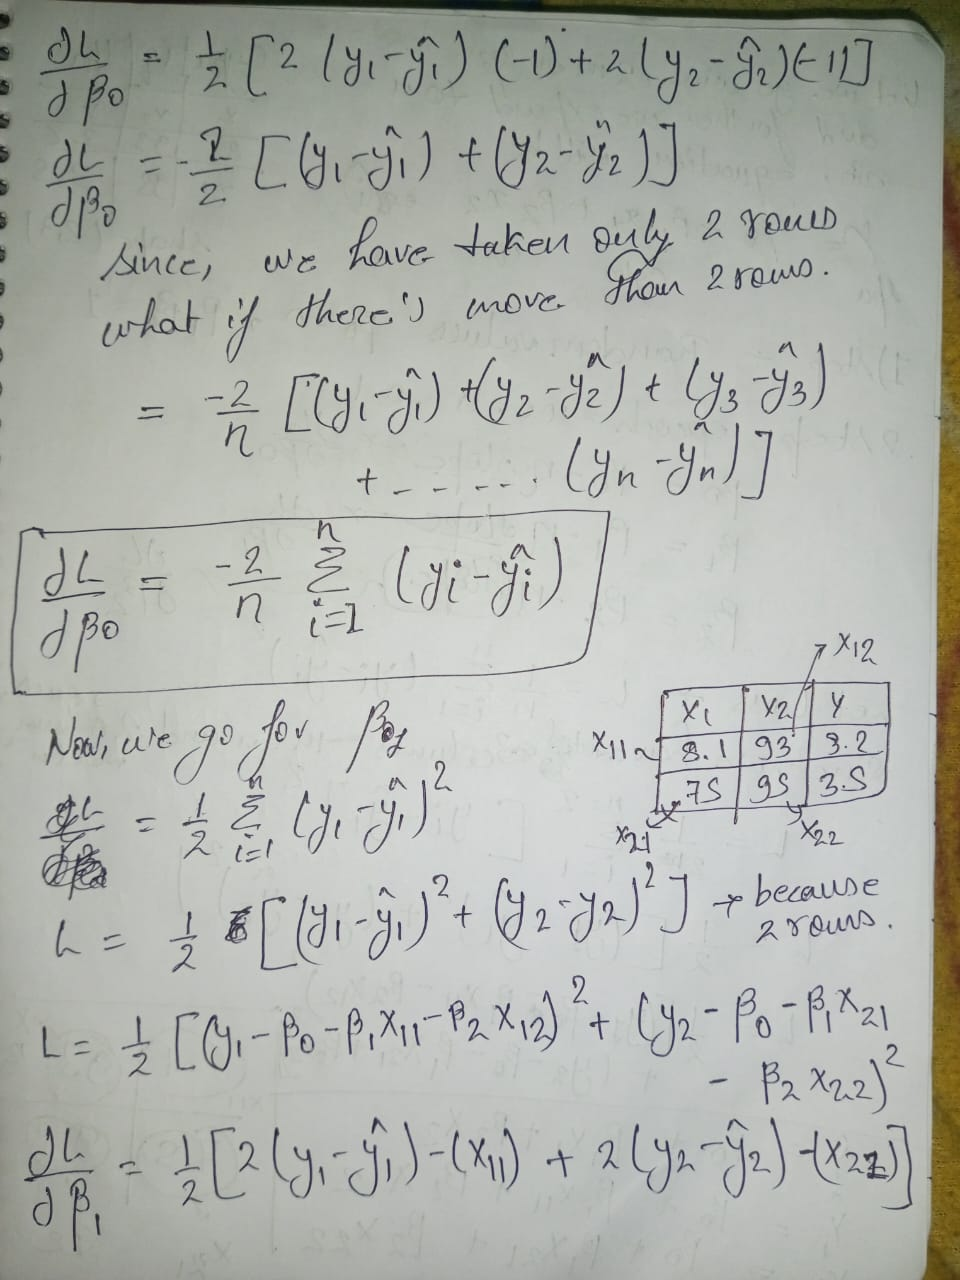

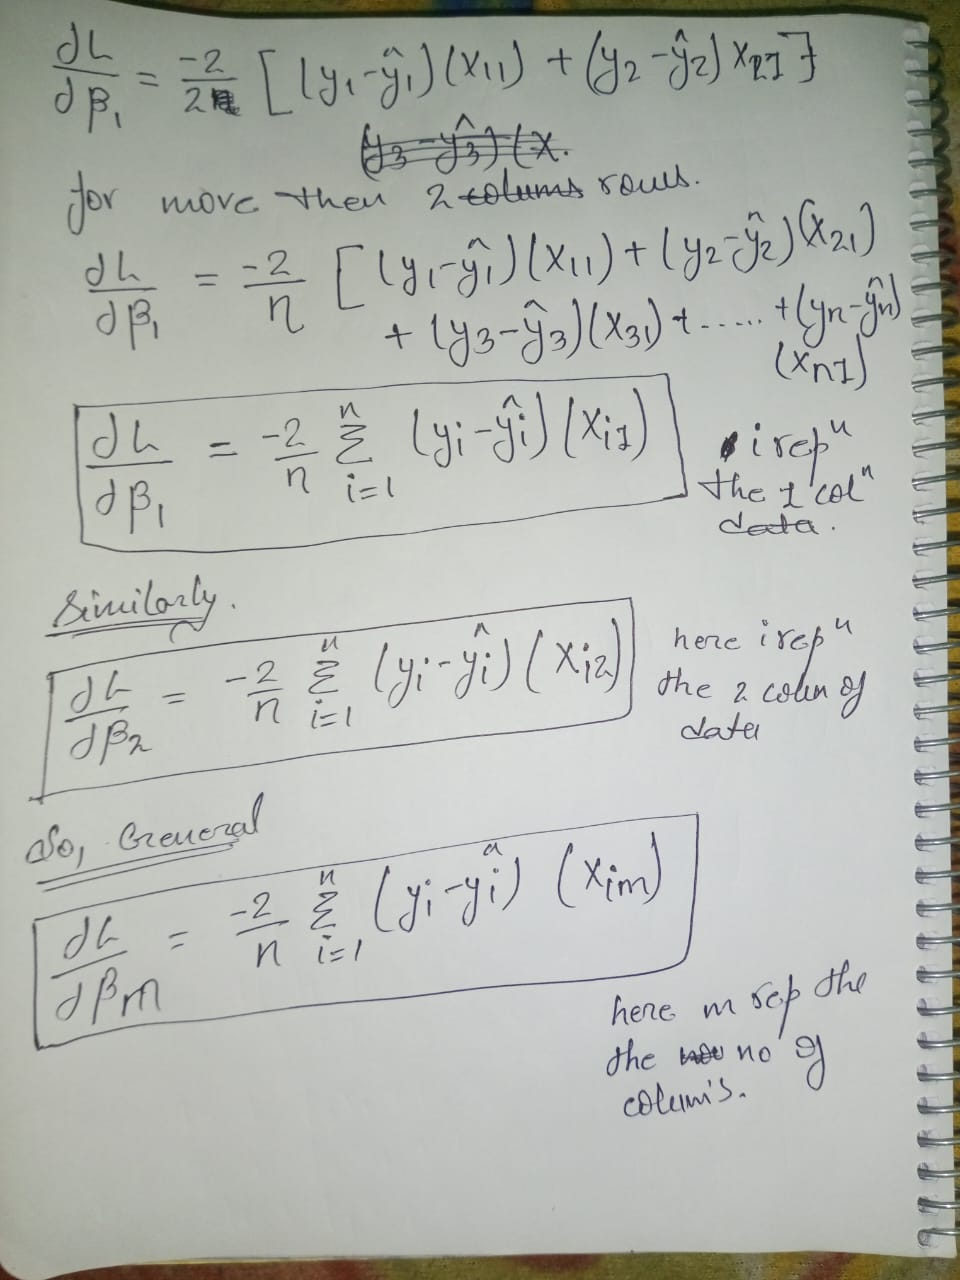

| Type                    | Data used per update | Pros                          | Cons                    |
| ----------------------- | -------------------- | ----------------------------- | ----------------------- |
| **Batch GD**            | All samples          | Stable, accurate              | Slow for large data     |
| **Stochastic GD (SGD)** | 1 sample             | Fast, can escape local minima | Noisy updates           |
| **Mini-batch GD**       | Small batch          | Balanced speed & stability    | Needs batch size tuning |


----

-----

In [11]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [13]:
X,y = load_diabetes(return_X_y=True)

In [15]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [19]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [21]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [23]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [25]:
X_train.shape

(353, 10)

## we define the above to know the the  coef_ and intercept_

In [40]:
class GDRegressor:

    def __init__(self,lr=0.01,epochs=100):
        self.lr=lr
        self.epochs=epochs
        self.intercept_=None
        self.coef_=None

    def fit(self,X_train,y_train):
        self.intercept_=0
        self.coef_=np.ones(X_train.shape)[1] # to define 10 coef_  as 1

        for i in range(self.epochs):
            # update all the coef and the intercept
            ## y=beta_not + b1 x1 +b2 x2 +....
            ##y_hat=
                
            y_hat=np.dot(X_train,self.coef_)+self.intercept_  ## y_hate = The predicted value of y given by your model. on X_train data
            
            intercept_der = -2*np.mean(y_train - y_hat) ## beta_not= -2/n  sum (y-y_hat)
            self.intercept_=self.intercept_ -(self.lr * intercept_der)

            coef_der= -2 * np.dot((y_train-y_hat),X_train)/X_train.shape[0]
            self.coef_=self.coef_-(self.lr * coef_der)
        print(self.intercept_,self.coef_)
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [189]:
BGD=GDRegressor(epochs=10000,lr=.05)

In [191]:
BGD.fit(X_train,y_train)

152.01361625633209 [  14.42082021 -173.64320014  491.45738721  323.86648691  -39.29054414
 -115.94237418 -194.02742733  103.3998093   451.56034806   97.5906554 ]


In [192]:
y_pred=BGD.predict(X_test)

In [195]:
r2_score(y_test,y_pred)

0.45345334222444034

# so r2_score of our model is greater then the above r2_score